# 👗 Fashion MNIST Image Classification
## Complete Notebook: EDA → Modeling → Evaluasi

**Dataset**: Fashion MNIST — 70.000 gambar pakaian & aksesori (Zalando Research)  
**Framework**: TensorFlow / Keras  

---
### 📋 Struktur Notebook
| Part | Isi |
|---|---|
| **Part 1** | Data Exploration & Preprocessing |
| **Part 2** | Modeling & Training (Dense NN vs CNN) |
| **Part 3** | Evaluasi & Visualisasi |

> ⚡ Aktifkan GPU: `Runtime → Change runtime type → T4 GPU`

## 1. Install & Import Libraries

In [1]:
# TensorFlow sudah tersedia di Google Colab
# Pastikan versi terbaru
!pip install tensorflow -q

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras.utils import to_categorical

# Style
plt.rcParams.update({
    'figure.dpi'      : 110,
    'axes.spines.top' : False,
    'axes.spines.right': False,
})

print(f'✅ TensorFlow version : {tf.__version__}')
print(f'✅ Keras version      : {keras.__version__}')
print(f'✅ NumPy version      : {np.__version__}')

# Cek GPU
gpu = tf.config.list_physical_devices('GPU')
print(f'\n🖥️  GPU tersedia: {"Ya — training akan lebih cepat!" if gpu else "Tidak (pakai CPU)"}')

✅ TensorFlow version : 2.20.0
✅ Keras version      : 3.13.2
✅ NumPy version      : 2.0.2

🖥️  GPU tersedia: Ya — training akan lebih cepat!


## 2. Load Dataset

Fashion MNIST sudah built-in di Keras — tidak perlu download manual.

In [2]:
# Load langsung dari Keras (otomatis download ~30MB)
print('📥 Loading Fashion MNIST dataset...')
(X_train_raw, y_train_raw), (X_test_raw, y_test_raw) = fashion_mnist.load_data()

# Nama kategori
CLASS_NAMES = [
    'T-shirt/top',  # 0
    'Trouser',      # 1
    'Pullover',     # 2
    'Dress',        # 3
    'Coat',         # 4
    'Sandal',       # 5
    'Shirt',        # 6
    'Sneaker',      # 7
    'Bag',          # 8
    'Ankle boot'    # 9
]
NUM_CLASSES = len(CLASS_NAMES)

print(f'\n✅ Dataset berhasil dimuat!')
print(f'📊 Training set : {X_train_raw.shape[0]:,} gambar')
print(f'📊 Test set     : {X_test_raw.shape[0]:,} gambar')
print(f'📐 Ukuran gambar: {X_train_raw.shape[1]} × {X_train_raw.shape[2]} pixel (grayscale)')
print(f'🏷️  Jumlah kelas : {NUM_CLASSES} kategori')

📥 Loading Fashion MNIST dataset...
29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

✅ Dataset berhasil dimuat!
📊 Training set : 60,000 gambar
📊 Test set     : 10,000 gambar
📐 Ukuran gambar: 28 × 28 pixel (grayscale)
🏷️  Jumlah kelas : 10 kategori


## 3. Eksplorasi Awal

In [3]:
print('=' * 55)
print('📊 EKSPLORASI AWAL DATA')
print('=' * 55)

print(f'\n🔹 Shape X_train : {X_train_raw.shape}  → (jumlah, tinggi, lebar)')
print(f'🔹 Shape X_test  : {X_test_raw.shape}')
print(f'🔹 Shape y_train : {y_train_raw.shape}')
print(f'🔹 Shape y_test  : {y_test_raw.shape}')

print(f'\n🔹 Tipe data X   : {X_train_raw.dtype}')
print(f'🔹 Tipe data y   : {y_train_raw.dtype}')

print(f'\n🔹 Nilai pixel   : min={X_train_raw.min()}, max={X_train_raw.max()}')
print(f'   → Pixel dalam range 0–255 (uint8, belum dinormalisasi)')

print(f'\n🔹 Label unik    : {np.unique(y_train_raw)}')
print(f'🔹 Kelas         :')
for i, name in enumerate(CLASS_NAMES):
    count = np.sum(y_train_raw == i)
    print(f'   {i} = {name:<15} ({count:,} gambar)')

📊 EKSPLORASI AWAL DATA

🔹 Shape X_train : (60000, 28, 28)  → (jumlah, tinggi, lebar)
🔹 Shape X_test  : (10000, 28, 28)
🔹 Shape y_train : (60000,)
🔹 Shape y_test  : (10000,)

🔹 Tipe data X   : uint8
🔹 Tipe data y   : uint8

🔹 Nilai pixel   : min=0, max=255
   → Pixel dalam range 0–255 (uint8, belum dinormalisasi)

🔹 Label unik    : [0 1 2 3 4 5 6 7 8 9]
🔹 Kelas         :
   0 = T-shirt/top     (6,000 gambar)
   1 = Trouser         (6,000 gambar)
   2 = Pullover        (6,000 gambar)
   3 = Dress           (6,000 gambar)
   4 = Coat            (6,000 gambar)
   5 = Sandal          (6,000 gambar)
   6 = Shirt           (6,000 gambar)
   7 = Sneaker         (6,000 gambar)
   8 = Bag             (6,000 gambar)
   9 = Ankle boot      (6,000 gambar)


## 4. Visualisasi Sampel Gambar

Tampilkan satu contoh gambar dari tiap kategori.

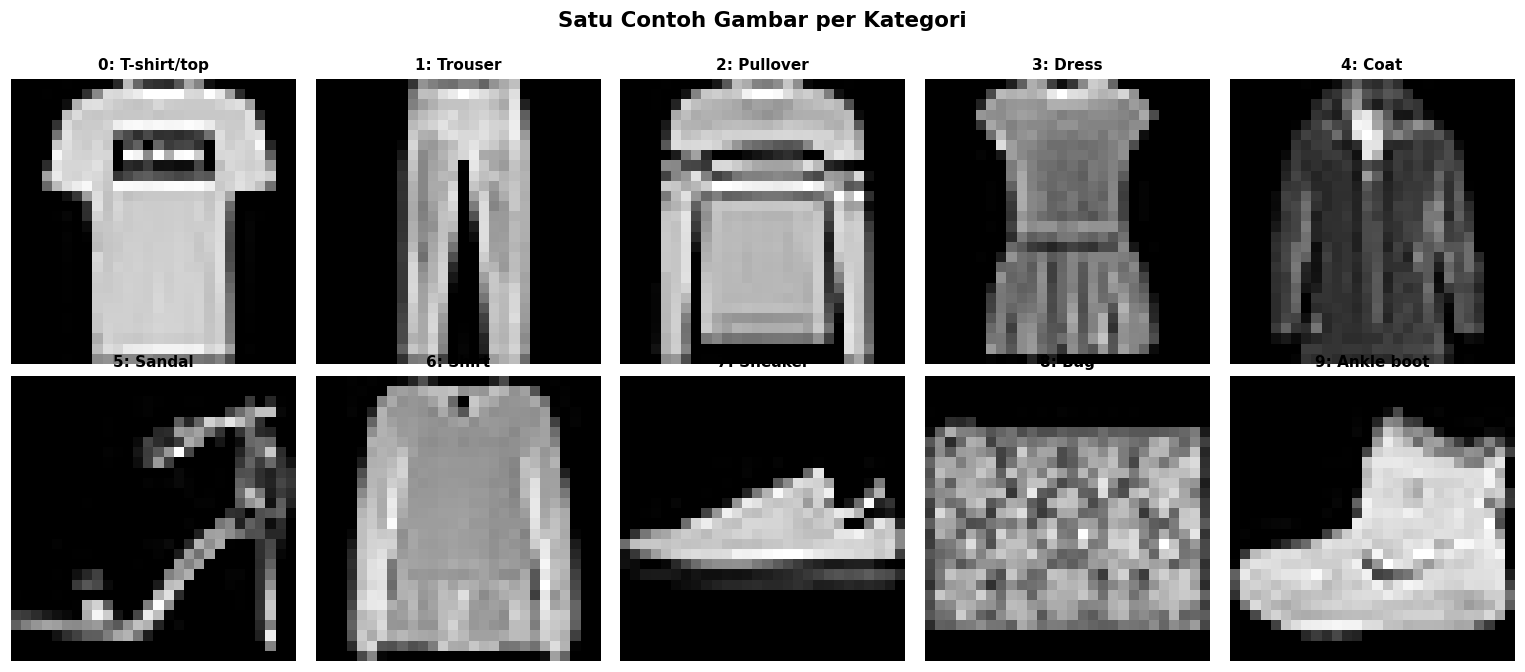

In [4]:
fig, axes = plt.subplots(2, 5, figsize=(14, 6))
axes = axes.flatten()

for i in range(NUM_CLASSES):
    # Ambil gambar pertama dari kelas i
    idx = np.where(y_train_raw == i)[0][0]
    axes[i].imshow(X_train_raw[idx], cmap='gray')
    axes[i].set_title(f'{i}: {CLASS_NAMES[i]}', fontsize=10, fontweight='bold')
    axes[i].axis('off')

plt.suptitle('Satu Contoh Gambar per Kategori', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

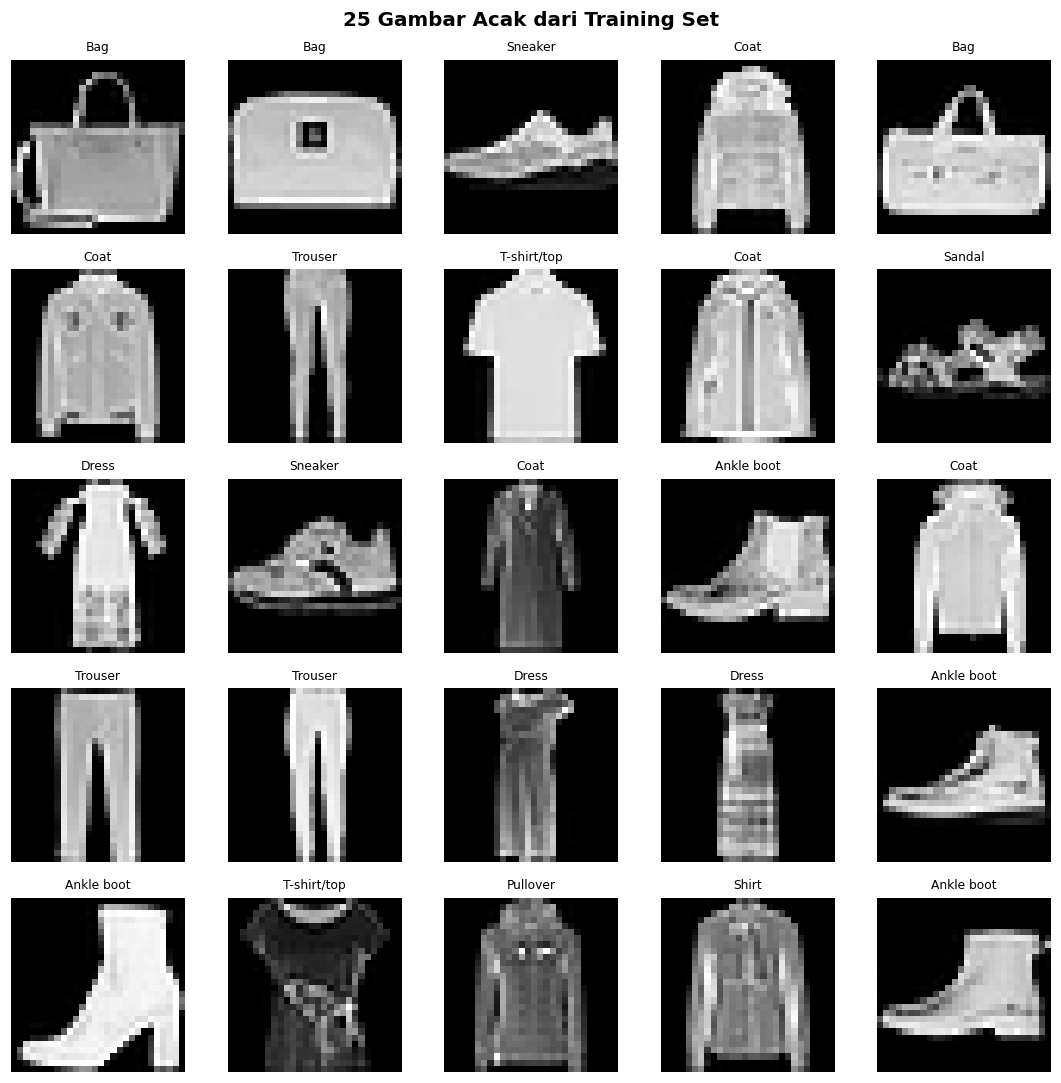

In [5]:
# Tampilkan 5x5 grid gambar acak dari training set
fig, axes = plt.subplots(5, 5, figsize=(10, 10))
axes = axes.flatten()

np.random.seed(42)
indices = np.random.choice(len(X_train_raw), 25, replace=False)

for i, idx in enumerate(indices):
    axes[i].imshow(X_train_raw[idx], cmap='gray')
    axes[i].set_title(CLASS_NAMES[y_train_raw[idx]], fontsize=8)
    axes[i].axis('off')

plt.suptitle('25 Gambar Acak dari Training Set', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

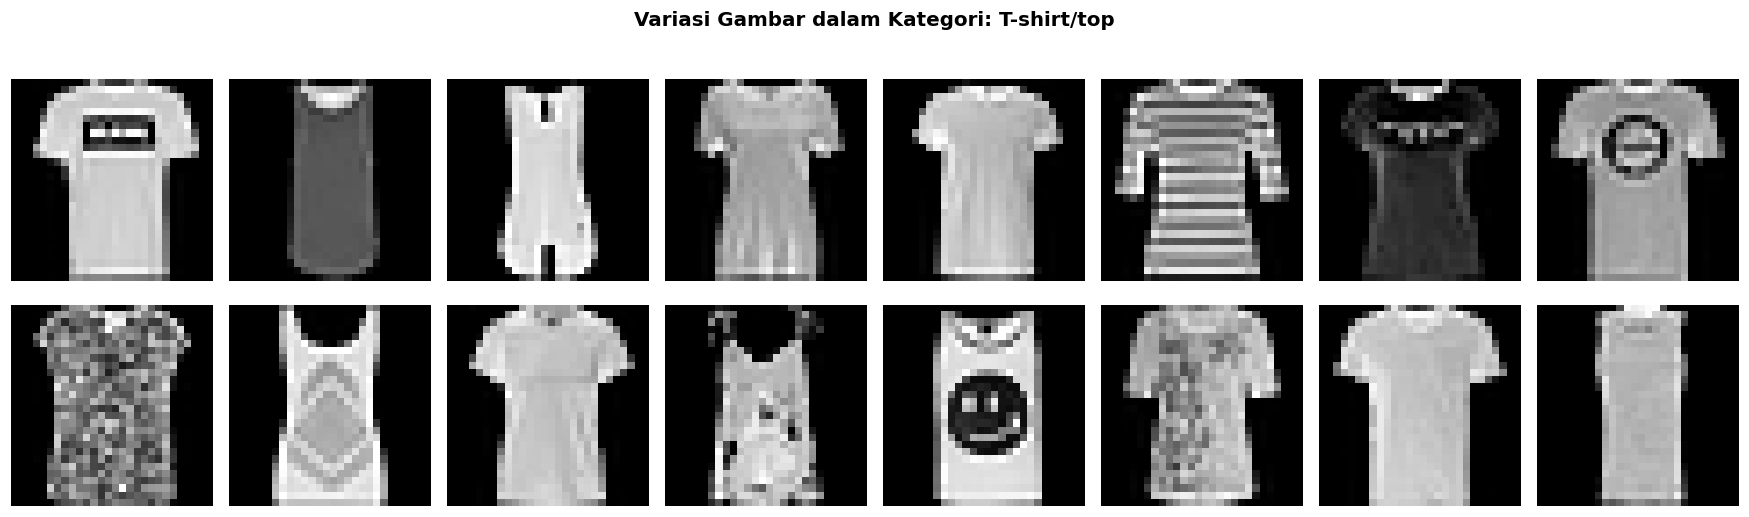

💡 Tip: Ganti nilai CATEGORY (0-9) untuk lihat variasi kategori lain


In [6]:
# Tampilkan variasi dalam satu kategori (misal: T-shirt)
CATEGORY = 0  # ganti angka untuk lihat kategori lain

fig, axes = plt.subplots(2, 8, figsize=(16, 5))
axes = axes.flatten()

indices_cat = np.where(y_train_raw == CATEGORY)[0][:16]
for i, idx in enumerate(indices_cat):
    axes[i].imshow(X_train_raw[idx], cmap='gray')
    axes[i].axis('off')

plt.suptitle(f'Variasi Gambar dalam Kategori: {CLASS_NAMES[CATEGORY]}',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('💡 Tip: Ganti nilai CATEGORY (0-9) untuk lihat variasi kategori lain')

## 5. Analisis Distribusi Kelas

Apakah jumlah data antar kelas seimbang? Ini penting karena dataset yang tidak seimbang bisa membuat model bias.

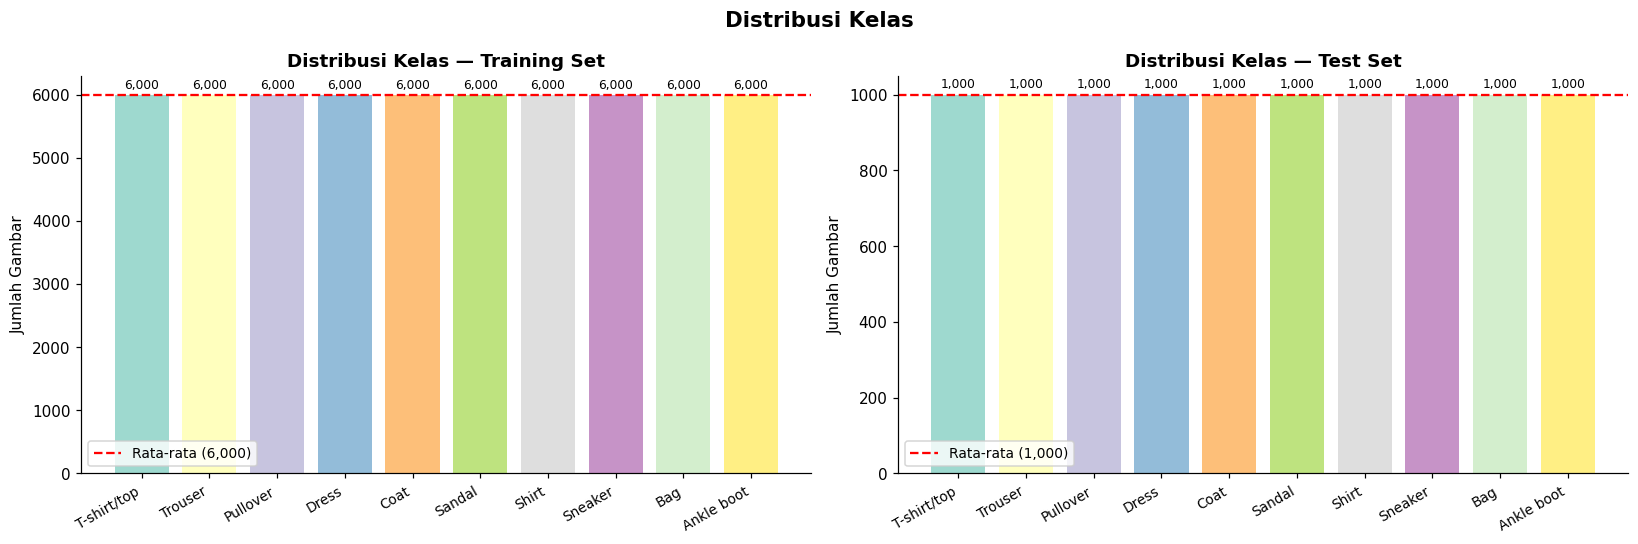


✅ Dataset seimbang: setiap kelas memiliki
   Training : 6,000 – 6,000 gambar per kelas
   Test     : 1,000 – 1,000 gambar per kelas

💡 Dataset ini sangat seimbang → tidak perlu oversampling/undersampling


In [7]:
train_counts = pd.Series(y_train_raw).value_counts().sort_index()
test_counts  = pd.Series(y_test_raw).value_counts().sort_index()

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Training set
colors = plt.cm.Set3(np.linspace(0, 1, NUM_CLASSES))
bars = axes[0].bar(range(NUM_CLASSES), train_counts.values, color=colors, alpha=0.85)
axes[0].set_xticks(range(NUM_CLASSES))
axes[0].set_xticklabels(CLASS_NAMES, rotation=30, ha='right', fontsize=9)
axes[0].set_title('Distribusi Kelas — Training Set', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Jumlah Gambar')
axes[0].axhline(train_counts.mean(), color='red', linestyle='--',
                linewidth=1.5, label=f'Rata-rata ({train_counts.mean():,.0f})')
axes[0].legend(fontsize=9)
for bar, val in zip(bars, train_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100,
                 f'{val:,}', ha='center', fontsize=8)

# Test set
bars2 = axes[1].bar(range(NUM_CLASSES), test_counts.values, color=colors, alpha=0.85)
axes[1].set_xticks(range(NUM_CLASSES))
axes[1].set_xticklabels(CLASS_NAMES, rotation=30, ha='right', fontsize=9)
axes[1].set_title('Distribusi Kelas — Test Set', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Jumlah Gambar')
axes[1].axhline(test_counts.mean(), color='red', linestyle='--',
                linewidth=1.5, label=f'Rata-rata ({test_counts.mean():,.0f})')
axes[1].legend(fontsize=9)
for bar, val in zip(bars2, test_counts.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
                 f'{val:,}', ha='center', fontsize=8)

plt.suptitle('Distribusi Kelas', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'\n✅ Dataset seimbang: setiap kelas memiliki')
print(f'   Training : {train_counts.min():,} – {train_counts.max():,} gambar per kelas')
print(f'   Test     : {test_counts.min():,} – {test_counts.max():,} gambar per kelas')
print(f'\n💡 Dataset ini sangat seimbang → tidak perlu oversampling/undersampling')

## 6. Analisis Pixel

Memahami distribusi nilai pixel sebelum normalisasi.

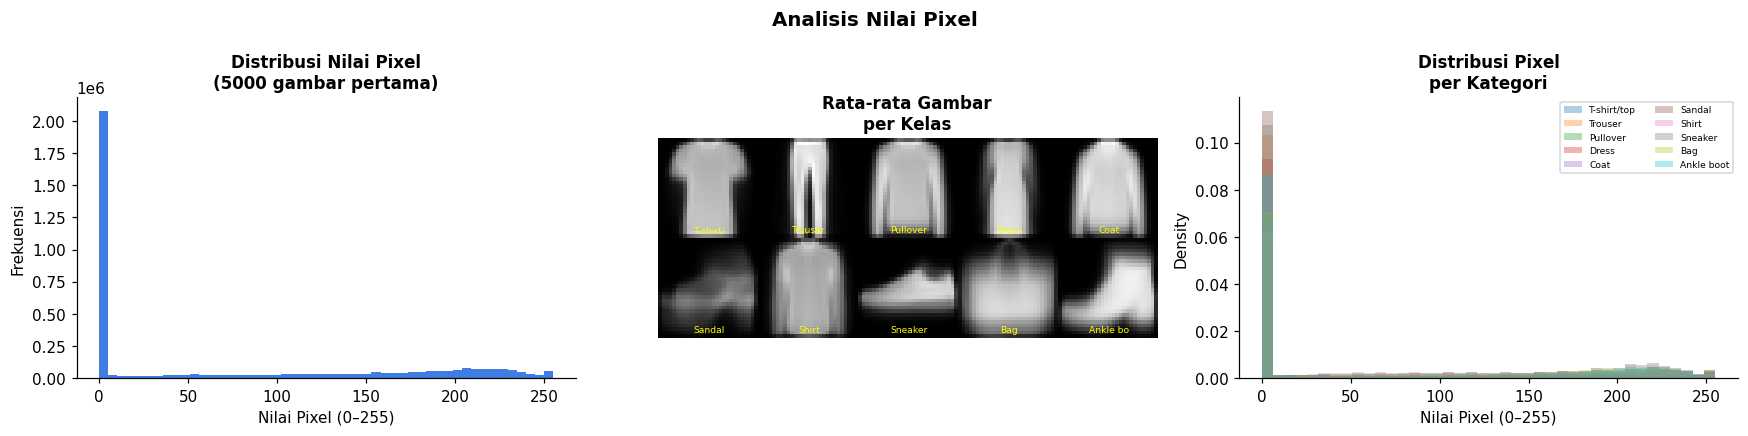

💡 Insight:
  • Banyak pixel bernilai 0 (hitam/background)
  • Pixel objek tersebar di range 64–255
  • Distribusi berbeda antar kategori → model bisa belajar perbedaan ini


In [8]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Plot 1: Distribusi pixel seluruh training set
sample_pixels = X_train_raw[:5000].flatten()
axes[0].hist(sample_pixels, bins=50, color='#0052D9', alpha=0.75, edgecolor='none')
axes[0].set_title('Distribusi Nilai Pixel\n(5000 gambar pertama)', fontsize=11, fontweight='bold')
axes[0].set_xlabel('Nilai Pixel (0–255)')
axes[0].set_ylabel('Frekuensi')

# Plot 2: Rata-rata gambar per kelas
mean_images = np.array([X_train_raw[y_train_raw == i].mean(axis=0) for i in range(NUM_CLASSES)])
grid = np.zeros((28*2, 28*5))
for i in range(NUM_CLASSES):
    r, c = i // 5, i % 5
    grid[r*28:(r+1)*28, c*28:(c+1)*28] = mean_images[i]
axes[1].imshow(grid, cmap='gray')
axes[1].set_title('Rata-rata Gambar\nper Kelas', fontsize=11, fontweight='bold')
axes[1].axis('off')
# Label
for i in range(NUM_CLASSES):
    r, c = i // 5, i % 5
    axes[1].text(c*28+14, r*28+26, CLASS_NAMES[i][:8],
                 ha='center', fontsize=6, color='yellow')

# Plot 3: Histogram pixel per kategori
colors_cat = plt.cm.tab10(np.linspace(0, 1, NUM_CLASSES))
for i in range(NUM_CLASSES):
    pixels = X_train_raw[y_train_raw == i].flatten()
    axes[2].hist(pixels, bins=40, alpha=0.35, color=colors_cat[i],
                 label=CLASS_NAMES[i], density=True)
axes[2].set_title('Distribusi Pixel\nper Kategori', fontsize=11, fontweight='bold')
axes[2].set_xlabel('Nilai Pixel (0–255)')
axes[2].set_ylabel('Density')
axes[2].legend(fontsize=6, ncol=2)

plt.suptitle('Analisis Nilai Pixel', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'💡 Insight:')
print(f'  • Banyak pixel bernilai 0 (hitam/background)')
print(f'  • Pixel objek tersebar di range 64–255')
print(f'  • Distribusi berbeda antar kategori → model bisa belajar perbedaan ini')

## 7. Preprocessing

Tiga langkah wajib sebelum data bisa dimasukkan ke model CNN:

| Langkah | Kenapa? |
|---|---|
| **Normalisasi** | Pixel 0–255 → 0–1 agar training lebih stabil & cepat |
| **Reshape** | Tambah dimensi channel (28,28) → (28,28,1) untuk CNN |
| **One-hot encoding** | Label angka → vektor biner untuk output model |

In [9]:
print('🔧 Preprocessing dimulai...')
print(f'   Input shape : {X_train_raw.shape}, dtype: {X_train_raw.dtype}')

# Step 1: Normalisasi (0-255 → 0.0-1.0)
X_train = X_train_raw.astype('float32') / 255.0
X_test  = X_test_raw.astype('float32')  / 255.0

print(f'\n✅ Step 1 — Normalisasi')
print(f'   Nilai pixel sebelum : min={X_train_raw.min()}, max={X_train_raw.max()}')
print(f'   Nilai pixel sesudah : min={X_train.min():.1f}, max={X_train.max():.1f}')

🔧 Preprocessing dimulai...
   Input shape : (60000, 28, 28), dtype: uint8

✅ Step 1 — Normalisasi
   Nilai pixel sebelum : min=0, max=255
   Nilai pixel sesudah : min=0.0, max=1.0


In [10]:
# Step 2: Reshape — tambah dimensi channel untuk CNN
# CNN butuh input shape: (batch, height, width, channels)
# Grayscale = 1 channel, RGB = 3 channel
X_train = X_train.reshape(-1, 28, 28, 1)
X_test  = X_test.reshape(-1, 28, 28, 1)

print(f'✅ Step 2 — Reshape')
print(f'   Shape sebelum : (60000, 28, 28)')
print(f'   Shape sesudah : {X_train.shape}  ← tambah dimensi channel')

✅ Step 2 — Reshape
   Shape sebelum : (60000, 28, 28)
   Shape sesudah : (60000, 28, 28, 1)  ← tambah dimensi channel


In [11]:
# Step 3: One-hot encoding label
# Contoh: label 3 (Dress) → [0, 0, 0, 1, 0, 0, 0, 0, 0, 0]
y_train_ohe = to_categorical(y_train_raw, num_classes=NUM_CLASSES)
y_test_ohe  = to_categorical(y_test_raw,  num_classes=NUM_CLASSES)

print(f'✅ Step 3 — One-hot Encoding')
print(f'   y_train shape  : {y_train_raw.shape} → {y_train_ohe.shape}')
print(f'\n   Contoh label asli → one-hot:')
for i in range(3):
    print(f'   Label {y_train_raw[i]} ({CLASS_NAMES[y_train_raw[i]]:<12}) → {y_train_ohe[i].astype(int)}')

✅ Step 3 — One-hot Encoding
   y_train shape  : (60000,) → (60000, 10)

   Contoh label asli → one-hot:
   Label 9 (Ankle boot  ) → [0 0 0 0 0 0 0 0 0 1]
   Label 0 (T-shirt/top ) → [1 0 0 0 0 0 0 0 0 0]
   Label 0 (T-shirt/top ) → [1 0 0 0 0 0 0 0 0 0]


## 8. Verifikasi & Simpan

In [12]:
print('=' * 55)
print('✅ RINGKASAN HASIL PREPROCESSING')
print('=' * 55)
print(f'''
DATA SIAP TRAINING:
  X_train : {X_train.shape}  dtype={X_train.dtype}
  X_test  : {X_test.shape}   dtype={X_test.dtype}
  y_train : {y_train_ohe.shape}       (one-hot encoded)
  y_test  : {y_test_ohe.shape}        (one-hot encoded)

NORMALISASI:
  Pixel range : 0.0 – 1.0 ✅

KELAS ({NUM_CLASSES} kategori):
''')
for i, name in enumerate(CLASS_NAMES):
    print(f'  {i} → {name}')

✅ RINGKASAN HASIL PREPROCESSING

DATA SIAP TRAINING:
  X_train : (60000, 28, 28, 1)  dtype=float32
  X_test  : (10000, 28, 28, 1)   dtype=float32
  y_train : (60000, 10)       (one-hot encoded)
  y_test  : (10000, 10)        (one-hot encoded)

NORMALISASI:
  Pixel range : 0.0 – 1.0 ✅

KELAS (10 kategori):

  0 → T-shirt/top
  1 → Trouser
  2 → Pullover
  3 → Dress
  4 → Coat
  5 → Sandal
  6 → Shirt
  7 → Sneaker
  8 → Bag
  9 → Ankle boot


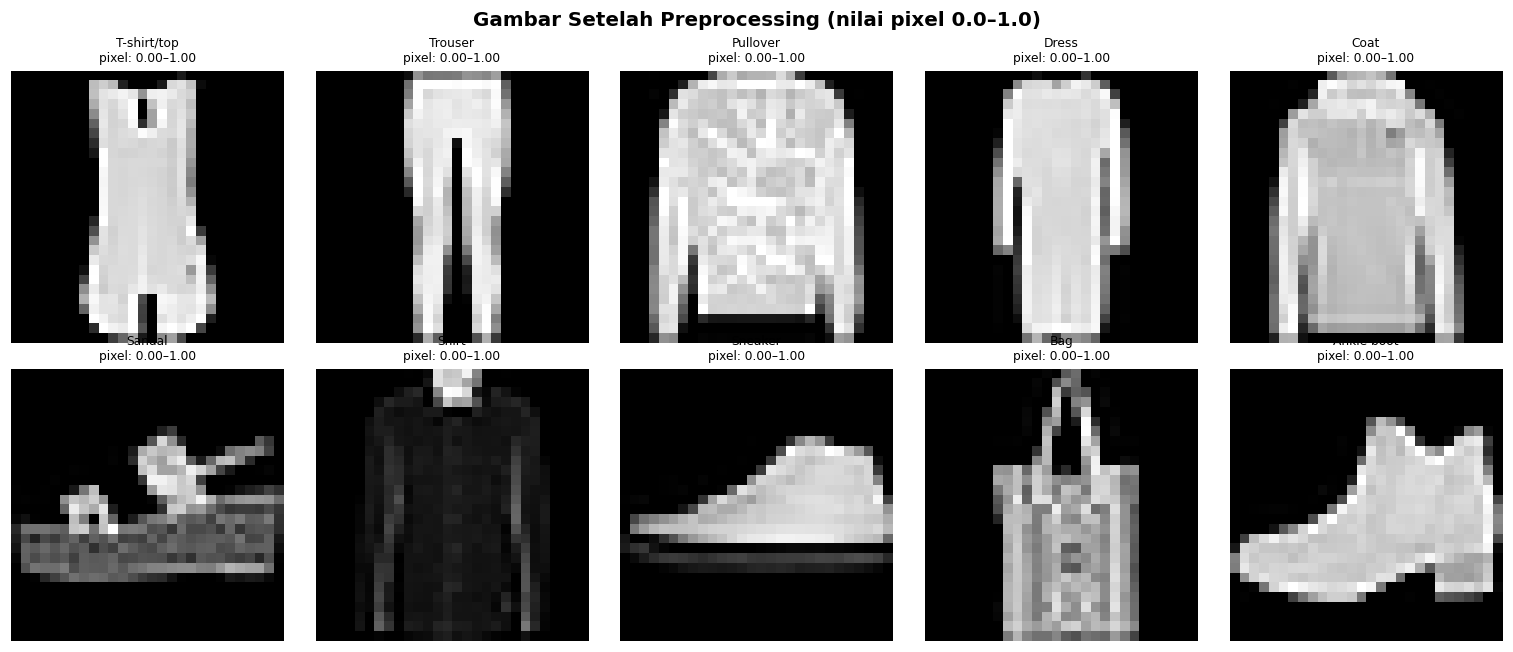

In [13]:
# Visualisasi final: gambar setelah preprocessing
fig, axes = plt.subplots(2, 5, figsize=(14, 6))
axes = axes.flatten()

for i in range(NUM_CLASSES):
    idx = np.where(y_train_raw == i)[0][2]
    axes[i].imshow(X_train[idx].reshape(28, 28), cmap='gray', vmin=0, vmax=1)
    axes[i].set_title(f'{CLASS_NAMES[i]}\npixel: {X_train[idx].min():.2f}–{X_train[idx].max():.2f}',
                      fontsize=8)
    axes[i].axis('off')

plt.suptitle('Gambar Setelah Preprocessing (nilai pixel 0.0–1.0)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [14]:
# Simpan data preprocessed untuk digunakan di Notebook 2
import os

np.save('X_train.npy', X_train)
np.save('X_test.npy',  X_test)
np.save('y_train.npy', y_train_ohe)
np.save('y_test.npy',  y_test_ohe)
np.save('y_train_raw.npy', y_train_raw)
np.save('y_test_raw.npy',  y_test_raw)

print('💾 File tersimpan:')
for fname in ['X_train.npy','X_test.npy','y_train.npy','y_test.npy',
              'y_train_raw.npy','y_test_raw.npy']:
    size = os.path.getsize(fname) / 1024 / 1024
    print(f'   {fname:<20} ({size:.1f} MB)')

print('\n🎉 Notebook 1 selesai! Lanjut → Notebook 2: Modeling & Training')

💾 File tersimpan:
   X_train.npy          (179.4 MB)
   X_test.npy           (29.9 MB)
   y_train.npy          (4.6 MB)
   y_test.npy           (0.8 MB)
   y_train_raw.npy      (0.1 MB)
   y_test_raw.npy       (0.0 MB)

🎉 Notebook 1 selesai! Lanjut → Notebook 2: Modeling & Training


---
# 🧠 Part 2: Modeling & Training
> Lanjutan Part 1 — pastikan semua cell di atas sudah dijalankan

## 1. Import & Load Data

In [15]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import (
    EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
)

# Style
plt.rcParams.update({'figure.dpi': 110, 'axes.spines.top': False,
                     'axes.spines.right': False})
BLUE   = '#0052D9'
ORANGE = '#FF6B35'
GREEN  = '#1DB954'
RED    = '#FF3B6B'

CLASS_NAMES = ['T-shirt/top','Trouser','Pullover','Dress','Coat',
               'Sandal','Shirt','Sneaker','Bag','Ankle boot']
NUM_CLASSES = 10

print(f'✅ TensorFlow : {tf.__version__}')
gpu = tf.config.list_physical_devices('GPU')
print(f'🖥️  GPU        : {"Aktif ⚡" if gpu else "Tidak aktif (CPU)"}')

✅ TensorFlow : 2.20.0
🖥️  GPU        : Aktif ⚡


In [16]:
# Load data preprocessed dari Notebook 1
X_train     = np.load('X_train.npy')
X_test      = np.load('X_test.npy')
y_train     = np.load('y_train.npy')      # one-hot encoded
y_test      = np.load('y_test.npy')       # one-hot encoded
y_train_raw = np.load('y_train_raw.npy')  # label asli (integer)
y_test_raw  = np.load('y_test_raw.npy')

print('✅ Data berhasil dimuat!')
print(f'   X_train : {X_train.shape}  (float32, range 0–1)')
print(f'   X_test  : {X_test.shape}')
print(f'   y_train : {y_train.shape}  (one-hot)')
print(f'   y_test  : {y_test.shape}')

# Bagi training set jadi train + validation (80:20)
val_size  = int(len(X_train) * 0.2)
X_val     = X_train[-val_size:]
y_val     = y_train[-val_size:]
X_train_  = X_train[:-val_size]
y_train_  = y_train[:-val_size]

print(f'\n📊 Pembagian data:')
print(f'   Training   : {len(X_train_):,} gambar')
print(f'   Validation : {len(X_val):,} gambar')
print(f'   Test       : {len(X_test):,} gambar')

✅ Data berhasil dimuat!
   X_train : (60000, 28, 28, 1)  (float32, range 0–1)
   X_test  : (10000, 28, 28, 1)
   y_train : (60000, 10)  (one-hot)
   y_test  : (10000, 10)

📊 Pembagian data:
   Training   : 48,000 gambar
   Validation : 12,000 gambar
   Test       : 10,000 gambar


## 2. Model 1: Dense Neural Network (Baseline)

Model sederhana tanpa convolutional layer — digunakan sebagai **baseline** untuk dibandingkan dengan CNN.

```
Input (28×28×1)
    ↓ Flatten → 784 neuron
    ↓ Dense(512, ReLU) + Dropout(0.3)
    ↓ Dense(256, ReLU) + Dropout(0.3)
    ↓ Dense(10, Softmax) ← output probabilitas 10 kelas
```

In [17]:
def build_dense_model():
    model = models.Sequential([
        # Input
        layers.Input(shape=(28, 28, 1)),
        layers.Flatten(),

        # Hidden layers
        layers.Dense(512, activation='relu'),
        layers.Dropout(0.3),

        layers.Dense(256, activation='relu'),
        layers.Dropout(0.3),

        # Output layer
        layers.Dense(NUM_CLASSES, activation='softmax')
    ], name='DenseNN_Baseline')
    return model

model_dense = build_dense_model()
model_dense.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print('📋 Arsitektur Dense NN:')
model_dense.summary()

📋 Arsitektur Dense NN:


Model: "DenseNN_Baseline"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │       401,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 535,818 (2.04 MB)

 Trainable params: 535,818 (2.04 MB)

 Non-trainable params: 0 (0.00 B)

In [18]:
# Callbacks untuk Dense NN
callbacks_dense = [
    EarlyStopping(
        monitor='val_accuracy',
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=3,
        min_lr=1e-6,
        verbose=1
    )
]

print('⏳ Melatih Dense NN...')
history_dense = model_dense.fit(
    X_train_, y_train_,
    epochs=30,
    batch_size=128,
    validation_data=(X_val, y_val),
    callbacks=callbacks_dense,
    verbose=1
)

# Evaluasi di test set
loss_d, acc_d = model_dense.evaluate(X_test, y_test, verbose=0)
print(f'\n✅ Dense NN — Test Accuracy : {acc_d*100:.2f}%')
print(f'              Test Loss     : {loss_d:.4f}')

⏳ Melatih Dense NN...
Epoch 1/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 13s 13ms/step - accuracy: 0.7903 - loss: 0.5849 - val_accuracy: 0.8544 - val_loss: 0.4040 - learning_rate: 0.0010
Epoch 2/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.8475 - loss: 0.4162 - val_accuracy: 0.8642 - val_loss: 0.3749 - learning_rate: 0.0010
Epoch 3/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8602 - loss: 0.3784 - val_accuracy: 0.8670 - val_loss: 0.3578 - learning_rate: 0.0010
Epoch 4/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8676 - loss: 0.3614 - val_accuracy: 0.8756 - val_loss: 0.3400 - learning_rate: 0.0010
Epoch 5/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8729 - loss: 0.3418 - val_accuracy: 0.8698 - val_loss: 0.3540 - learning_rate: 0.0010
Epoch 6/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8787 - loss: 0.3276 - val_accuracy: 0.8738 - val_loss: 0.3388 - learning_rate: 0.0010
Epoch 7/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 

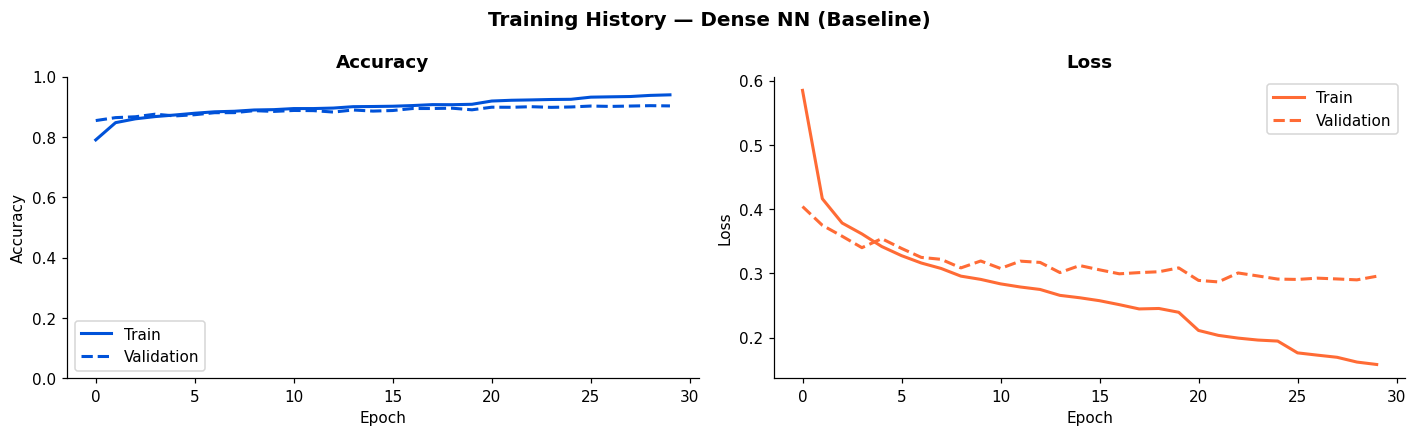

💡 Best val accuracy: 90.38%
   Total epochs     : 30


In [19]:
def plot_history(history, title, color_acc=BLUE, color_loss=ORANGE):
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))

    # Accuracy
    axes[0].plot(history.history['accuracy'],
                 color=color_acc, linewidth=2, label='Train')
    axes[0].plot(history.history['val_accuracy'],
                 color=color_acc, linewidth=2, linestyle='--', label='Validation')
    axes[0].set_title('Accuracy', fontsize=12, fontweight='bold')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Accuracy')
    axes[0].legend()
    axes[0].set_ylim(0, 1)

    # Loss
    axes[1].plot(history.history['loss'],
                 color=color_loss, linewidth=2, label='Train')
    axes[1].plot(history.history['val_loss'],
                 color=color_loss, linewidth=2, linestyle='--', label='Validation')
    axes[1].set_title('Loss', fontsize=12, fontweight='bold')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Loss')
    axes[1].legend()

    plt.suptitle(title, fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

plot_history(history_dense, 'Training History — Dense NN (Baseline)')

best_val = max(history_dense.history['val_accuracy'])
print(f'💡 Best val accuracy: {best_val*100:.2f}%')
print(f'   Total epochs     : {len(history_dense.history["accuracy"])}')

## 3. Model 2: CNN — Convolutional Neural Network (Model Utama)

CNN dirancang khusus untuk data gambar. Convolutional layer belajar mendeteksi fitur visual seperti tepi, tekstur, dan pola — yang tidak bisa dilakukan Dense NN.

```
Input (28×28×1)
    ↓ Conv2D(32, 3×3) + BatchNorm + ReLU
    ↓ Conv2D(32, 3×3) + BatchNorm + ReLU
    ↓ MaxPooling(2×2) + Dropout(0.25)
    ↓
    ↓ Conv2D(64, 3×3) + BatchNorm + ReLU
    ↓ Conv2D(64, 3×3) + BatchNorm + ReLU
    ↓ MaxPooling(2×2) + Dropout(0.25)
    ↓
    ↓ Flatten
    ↓ Dense(256, ReLU) + BatchNorm + Dropout(0.5)
    ↓ Dense(10, Softmax)
```

In [20]:
def build_cnn_model():
    model = models.Sequential(name='CNN_Main')

    # ── Block 1 ──────────────────────────────────────
    model.add(layers.Input(shape=(28, 28, 1)))

    model.add(layers.Conv2D(32, (3, 3), padding='same'))
    model.add(layers.BatchNormalization())
    model.add(layers.Activation('relu'))

    model.add(layers.Conv2D(32, (3, 3), padding='same'))
    model.add(layers.BatchNormalization())
    model.add(layers.Activation('relu'))

    model.add(layers.MaxPooling2D((2, 2)))
    model.add(layers.Dropout(0.25))

    # ── Block 2 ──────────────────────────────────────
    model.add(layers.Conv2D(64, (3, 3), padding='same'))
    model.add(layers.BatchNormalization())
    model.add(layers.Activation('relu'))

    model.add(layers.Conv2D(64, (3, 3), padding='same'))
    model.add(layers.BatchNormalization())
    model.add(layers.Activation('relu'))

    model.add(layers.MaxPooling2D((2, 2)))
    model.add(layers.Dropout(0.25))

    # ── Classifier ───────────────────────────────────
    model.add(layers.Flatten())
    model.add(layers.Dense(256))
    model.add(layers.BatchNormalization())
    model.add(layers.Activation('relu'))
    model.add(layers.Dropout(0.5))

    model.add(layers.Dense(NUM_CLASSES, activation='softmax'))

    return model

model_cnn = build_cnn_model()
model_cnn.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print('📋 Arsitektur CNN:')
model_cnn.summary()

📋 Arsitektur CNN:


Model: "CNN_Main"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 28, 28, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 14, 14, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 256)            │       803,072 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴─────────────

 Total params: 872,426 (3.33 MB)

 Trainable params: 871,530 (3.32 MB)

 Non-trainable params: 896 (3.50 KB)

In [21]:
# Callbacks untuk CNN
callbacks_cnn = [
    EarlyStopping(
        monitor='val_accuracy',
        patience=7,
        restore_best_weights=True,
        verbose=1
    ),
    ModelCheckpoint(
        'best_cnn_model.keras',
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=3,
        min_lr=1e-6,
        verbose=1
    )
]

print('⏳ Melatih CNN... (dengan GPU ~3-5 menit, CPU ~20-30 menit)')
history_cnn = model_cnn.fit(
    X_train_, y_train_,
    epochs=50,
    batch_size=128,
    validation_data=(X_val, y_val),
    callbacks=callbacks_cnn,
    verbose=1
)

# Evaluasi di test set
loss_c, acc_c = model_cnn.evaluate(X_test, y_test, verbose=0)
print(f'\n✅ CNN — Test Accuracy : {acc_c*100:.2f}%')
print(f'         Test Loss     : {loss_c:.4f}')

⏳ Melatih CNN... (dengan GPU ~3-5 menit, CPU ~20-30 menit)
Epoch 1/50
372/375 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7555 - loss: 0.7049
Epoch 1: val_accuracy improved from None to 0.65267, saving model to best_cnn_model.keras

Epoch 1: finished saving model to best_cnn_model.keras
375/375 ━━━━━━━━━━━━━━━━━━━━ 16s 15ms/step - accuracy: 0.8256 - loss: 0.4899 - val_accuracy: 0.6527 - val_loss: 0.9831 - learning_rate: 0.0010
Epoch 2/50
374/375 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8828 - loss: 0.3215
Epoch 2: val_accuracy improved from 0.65267 to 0.90817, saving model to best_cnn_model.keras

Epoch 2: finished saving model to best_cnn_model.keras
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.8860 - loss: 0.3146 - val_accuracy: 0.9082 - val_loss: 0.2490 - learning_rate: 0.0010
Epoch 3/50
371/375 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9026 - loss: 0.2687
Epoch 3: val_accuracy improved from 0.90817 to 0.91300, saving model to best_cnn_model.keras

Epoch 

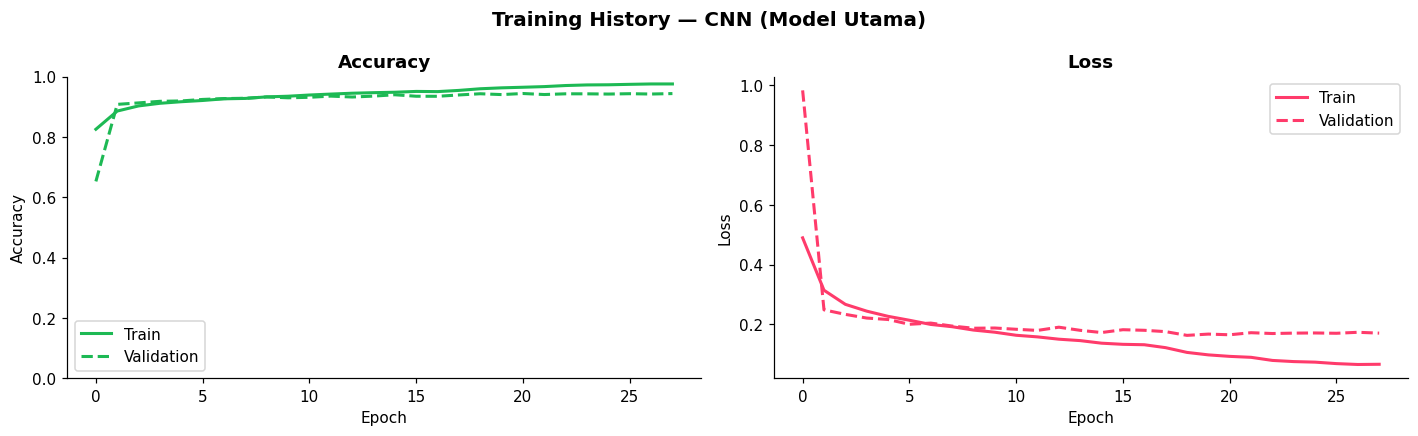

💡 Best val accuracy: 94.42%
   Total epochs     : 28


In [22]:
plot_history(history_cnn, 'Training History — CNN (Model Utama)',
             color_acc=GREEN, color_loss=RED)

best_val_cnn = max(history_cnn.history['val_accuracy'])
print(f'💡 Best val accuracy: {best_val_cnn*100:.2f}%')
print(f'   Total epochs     : {len(history_cnn.history["accuracy"])}')

## 4. Perbandingan Model

📊 PERBANDINGAN DENSE NN vs CNN
              Model Test Accuracy Test Loss Total Params
Dense NN (Baseline)        89.93%    0.3170      535,818
         CNN (Main)        93.93%    0.1830      872,426


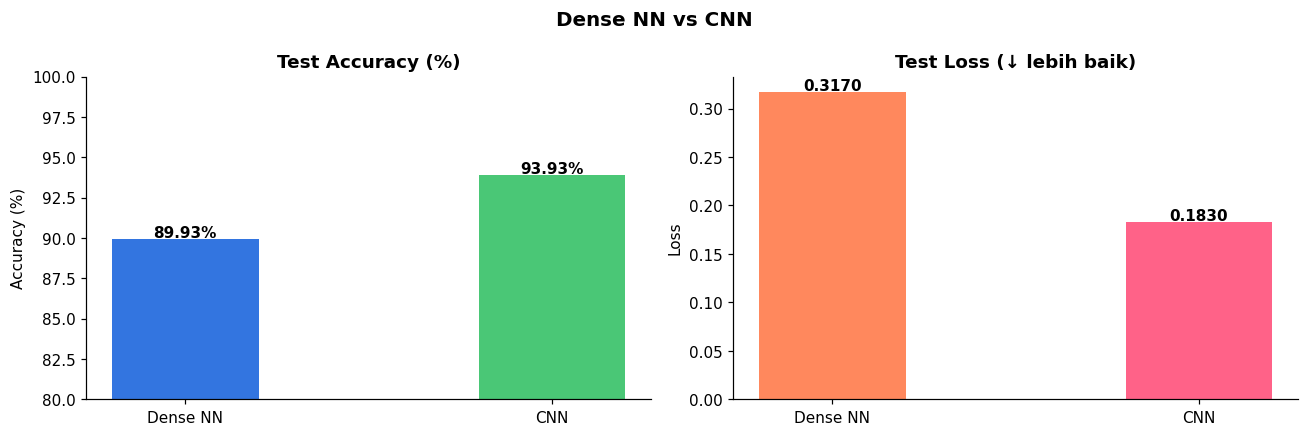


🏆 CNN lebih baik 4.00% dari Dense NN


In [23]:
print('=' * 55)
print('📊 PERBANDINGAN DENSE NN vs CNN')
print('=' * 55)

import pandas as pd
results = pd.DataFrame({
    'Model'          : ['Dense NN (Baseline)', 'CNN (Main)'],
    'Test Accuracy'  : [f'{acc_d*100:.2f}%', f'{acc_c*100:.2f}%'],
    'Test Loss'      : [f'{loss_d:.4f}', f'{loss_c:.4f}'],
    'Total Params'   : [
        f"{model_dense.count_params():,}",
        f"{model_cnn.count_params():,}"
    ]
})
print(results.to_string(index=False))

# Bar chart perbandingan
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

models_name = ['Dense NN', 'CNN']
accs  = [acc_d * 100, acc_c * 100]
losses = [loss_d, loss_c]

bars1 = axes[0].bar(models_name, accs, color=[BLUE, GREEN], alpha=0.8, width=0.4)
axes[0].set_title('Test Accuracy (%)', fontsize=12, fontweight='bold')
axes[0].set_ylim(80, 100)
axes[0].set_ylabel('Accuracy (%)')
for bar, val in zip(bars1, accs):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.1,
                 f'{val:.2f}%', ha='center', fontweight='bold')

bars2 = axes[1].bar(models_name, losses, color=[ORANGE, RED], alpha=0.8, width=0.4)
axes[1].set_title('Test Loss (↓ lebih baik)', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Loss')
for bar, val in zip(bars2, losses):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.002,
                 f'{val:.4f}', ha='center', fontweight='bold')

plt.suptitle('Dense NN vs CNN', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

improvement = (acc_c - acc_d) * 100
print(f'\n🏆 CNN lebih baik {improvement:.2f}% dari Dense NN')

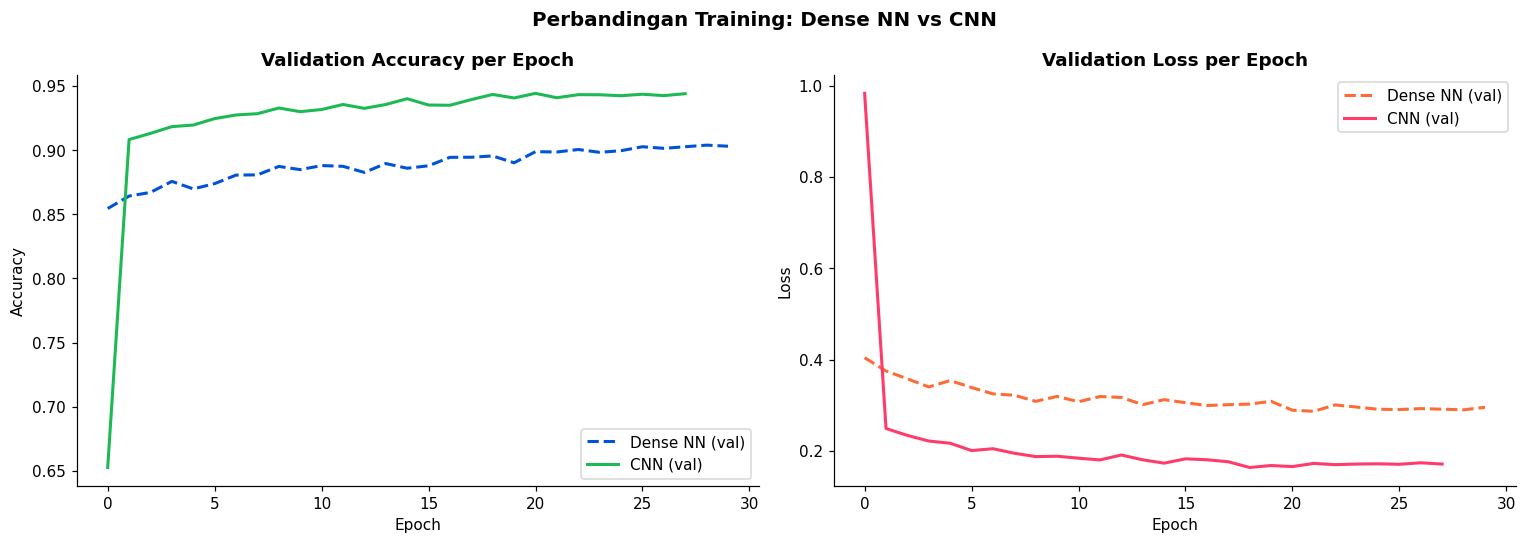

In [24]:
# Plot training history kedua model bersama
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy
axes[0].plot(history_dense.history['val_accuracy'],
             color=BLUE, linewidth=2, linestyle='--', label='Dense NN (val)')
axes[0].plot(history_cnn.history['val_accuracy'],
             color=GREEN, linewidth=2, label='CNN (val)')
axes[0].set_title('Validation Accuracy per Epoch', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()

# Loss
axes[1].plot(history_dense.history['val_loss'],
             color=ORANGE, linewidth=2, linestyle='--', label='Dense NN (val)')
axes[1].plot(history_cnn.history['val_loss'],
             color=RED, linewidth=2, label='CNN (val)')
axes[1].set_title('Validation Loss per Epoch', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()

plt.suptitle('Perbandingan Training: Dense NN vs CNN', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 5. Simpan Model

In [25]:
# Simpan kedua model
model_dense.save('model_dense.keras')
model_cnn.save('model_cnn.keras')

print('💾 Model tersimpan:')
print('   model_dense.keras  ← Dense NN baseline')
print('   model_cnn.keras    ← CNN model utama')
print('   best_cnn_model.keras ← CNN dengan val_accuracy terbaik')

# Download model terbaik ke komputer
from google.colab import files
files.download('best_cnn_model.keras')
print('\n📥 best_cnn_model.keras siap didownload!')

💾 Model tersimpan:
   model_dense.keras  ← Dense NN baseline
   model_cnn.keras    ← CNN model utama
   best_cnn_model.keras ← CNN dengan val_accuracy terbaik


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


📥 best_cnn_model.keras siap didownload!


In [26]:
print('=' * 55)
print('✅ RINGKASAN NOTEBOOK 2')
print('=' * 55)
print(f'''
MODEL 1 — Dense NN (Baseline)
  Test Accuracy : {acc_d*100:.2f}%
  Test Loss     : {loss_d:.4f}
  Parameter     : {model_dense.count_params():,}

MODEL 2 — CNN (Main)
  Test Accuracy : {acc_c*100:.2f}%
  Test Loss     : {loss_c:.4f}
  Parameter     : {model_cnn.count_params():,}

Peningkatan CNN vs Dense NN: +{(acc_c-acc_d)*100:.2f}%

OUTPUT FILE:
  ✅ model_dense.keras
  ✅ model_cnn.keras
  ✅ best_cnn_model.keras
''')
print('🎉 Notebook 2 selesai! Lanjut → Notebook 3: Evaluasi & Visualisasi')

✅ RINGKASAN NOTEBOOK 2

MODEL 1 — Dense NN (Baseline)
  Test Accuracy : 89.93%
  Test Loss     : 0.3170
  Parameter     : 535,818

MODEL 2 — CNN (Main)
  Test Accuracy : 93.93%
  Test Loss     : 0.1830
  Parameter     : 872,426

Peningkatan CNN vs Dense NN: +4.00%

OUTPUT FILE:
  ✅ model_dense.keras
  ✅ model_cnn.keras
  ✅ best_cnn_model.keras

🎉 Notebook 2 selesai! Lanjut → Notebook 3: Evaluasi & Visualisasi


---
# 📊 Part 3: Evaluasi & Visualisasi
> Lanjutan Part 2 — model dan data sudah tersedia di memori

## 1. Import & Load Model

In [27]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow import keras
from sklearn.metrics import (
    classification_report, confusion_matrix
)

plt.rcParams.update({'figure.dpi': 110,
                     'axes.spines.top': False,
                     'axes.spines.right': False})
BLUE   = '#0052D9'
ORANGE = '#FF6B35'
GREEN  = '#1DB954'
RED    = '#FF3B6B'

CLASS_NAMES = ['T-shirt/top','Trouser','Pullover','Dress','Coat',
               'Sandal','Shirt','Sneaker','Bag','Ankle boot']
NUM_CLASSES = 10

print(f'✅ TensorFlow : {tf.__version__}')

✅ TensorFlow : 2.20.0


In [28]:
# Load data test
X_test      = np.load('X_test.npy')
y_test      = np.load('y_test.npy')
y_test_raw  = np.load('y_test_raw.npy')

# Load model CNN terbaik
model_cnn   = keras.models.load_model('best_cnn_model.keras')
model_dense = keras.models.load_model('model_dense.keras')

print('✅ Data dan model berhasil dimuat!')
print(f'   X_test  : {X_test.shape}')
print(f'   y_test  : {y_test.shape}')

✅ Data dan model berhasil dimuat!
   X_test  : (10000, 28, 28, 1)
   y_test  : (10000, 10)


## 2. Evaluasi Test Set

In [29]:
# Prediksi probabilitas & label
y_pred_prob  = model_cnn.predict(X_test, verbose=0)
y_pred_label = np.argmax(y_pred_prob, axis=1)
y_true_label = y_test_raw

# Evaluasi
loss_c, acc_c   = model_cnn.evaluate(X_test, y_test, verbose=0)
loss_d, acc_d   = model_dense.evaluate(X_test, y_test, verbose=0)

print('=' * 55)
print('📊 EVALUASI TEST SET')
print('=' * 55)
print(f'\n  Dense NN → Accuracy: {acc_d*100:.2f}%  Loss: {loss_d:.4f}')
print(f'  CNN      → Accuracy: {acc_c*100:.2f}%  Loss: {loss_c:.4f}')
print(f'\n  Peningkatan CNN vs Dense NN: +{(acc_c-acc_d)*100:.2f}%')
print(f'\n  Dari {len(y_test_raw):,} gambar test:')
n_correct = np.sum(y_pred_label == y_true_label)
n_wrong   = len(y_true_label) - n_correct
print(f'  ✅ Prediksi benar : {n_correct:,} gambar ({acc_c*100:.2f}%)')
print(f'  ❌ Prediksi salah : {n_wrong:,} gambar ({(1-acc_c)*100:.2f}%)')

📊 EVALUASI TEST SET

  Dense NN → Accuracy: 89.93%  Loss: 0.3170
  CNN      → Accuracy: 93.93%  Loss: 0.1830

  Peningkatan CNN vs Dense NN: +4.00%

  Dari 10,000 gambar test:
  ✅ Prediksi benar : 9,393 gambar (93.93%)
  ❌ Prediksi salah : 607 gambar (6.07%)


## 3. Confusion Matrix

Confusion matrix memperlihatkan **prediksi vs label asli** untuk tiap kelas — kita bisa lihat persis kelas mana yang sering tertukar.

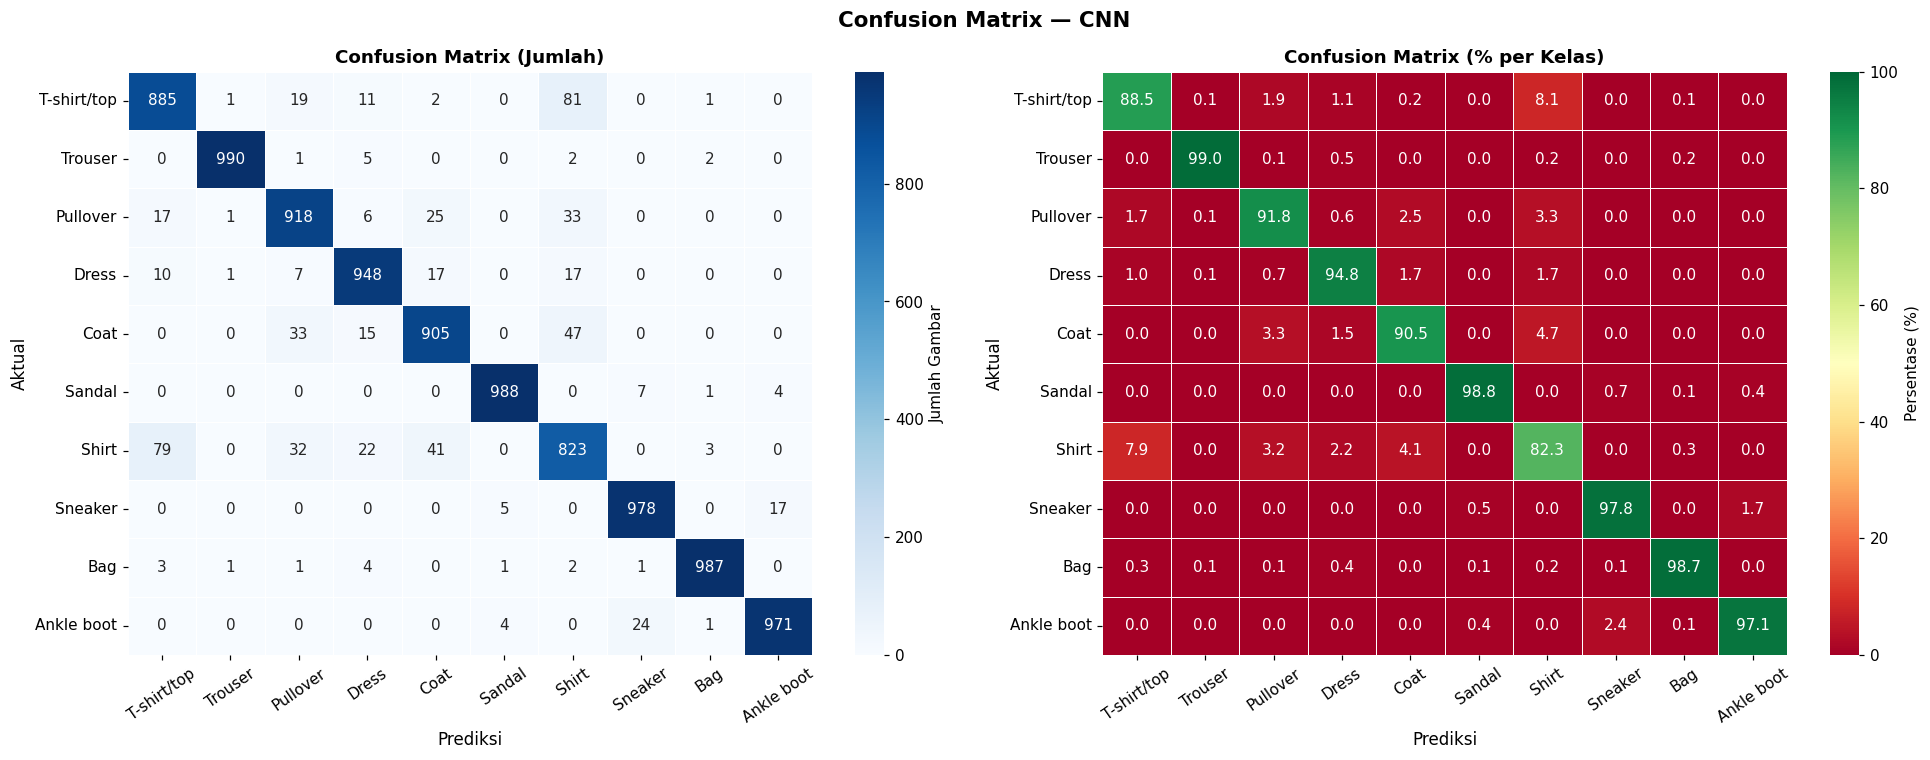


⚠️  Pasangan paling sering tertukar:
   T-shirt/top → salah diprediksi sebagai Shirt
   (81 kali dari 1000 gambar)


In [30]:
cm = confusion_matrix(y_true_label, y_pred_label)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Plot 1: Confusion matrix (jumlah absolut)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
            ax=axes[0], linewidths=0.5, linecolor='white',
            cbar_kws={'label': 'Jumlah Gambar'})
axes[0].set_title('Confusion Matrix (Jumlah)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Prediksi', fontsize=11)
axes[0].set_ylabel('Aktual', fontsize=11)
axes[0].tick_params(axis='x', rotation=35)

# Plot 2: Confusion matrix (persentase per kelas)
cm_pct = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100
sns.heatmap(cm_pct, annot=True, fmt='.1f', cmap='RdYlGn',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
            ax=axes[1], linewidths=0.5, linecolor='white',
            vmin=0, vmax=100,
            cbar_kws={'label': 'Persentase (%)'})
axes[1].set_title('Confusion Matrix (% per Kelas)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Prediksi', fontsize=11)
axes[1].set_ylabel('Aktual', fontsize=11)
axes[1].tick_params(axis='x', rotation=35)

plt.suptitle('Confusion Matrix — CNN', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Temukan pasangan yang sering tertukar
cm_nodiag = cm.copy()
np.fill_diagonal(cm_nodiag, 0)
most_confused = np.unravel_index(cm_nodiag.argmax(), cm_nodiag.shape)
print(f'\n⚠️  Pasangan paling sering tertukar:')
print(f'   {CLASS_NAMES[most_confused[0]]} → salah diprediksi sebagai {CLASS_NAMES[most_confused[1]]}')
print(f'   ({cm_nodiag[most_confused]} kali dari {cm[most_confused[0]].sum()} gambar)')

## 4. Classification Report

Precision, Recall, dan F1-Score per kelas — lebih detail dari sekadar accuracy.

📊 Classification Report:


,precision,recall,f1-score,support
T-shirt/top,0.890,0.885,0.888,1000.000
Trouser,0.996,0.990,0.993,1000.000
Pullover,0.908,0.918,0.913,1000.000
Dress,0.938,0.948,0.943,1000.000
Coat,0.914,0.905,0.910,1000.000
Sandal,0.990,0.988,0.989,1000.000
Shirt,0.819,0.823,0.821,1000.000
Sneaker,0.968,0.978,0.973,1000.000
Bag,0.992,0.987,0.989,1000.000
Ankle boot,0.979,0.971,0.975,1000.000


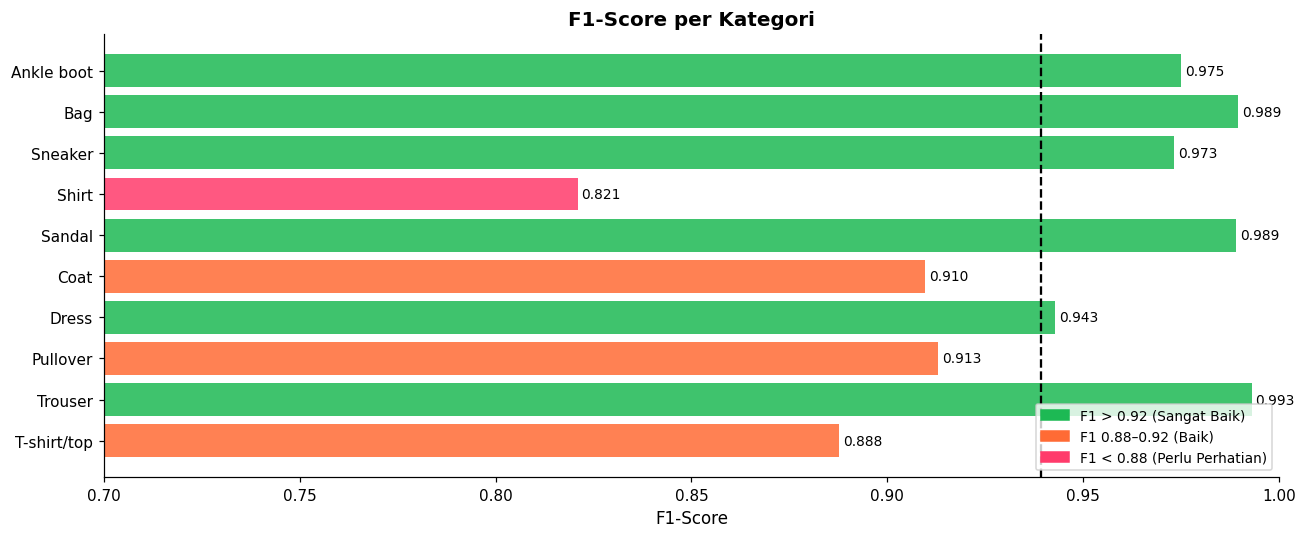


🏆 Kelas terbaik  : Trouser  (F1 = 0.993)
⚠️  Kelas tersulit : Shirt (F1 = 0.821)


In [31]:
report = classification_report(
    y_true_label, y_pred_label,
    target_names=CLASS_NAMES,
    output_dict=True
)
report_df = pd.DataFrame(report).T.round(3)

print('📊 Classification Report:')
display(report_df)

# Visualisasi F1-score per kelas
f1_scores = [report[cls]['f1-score'] for cls in CLASS_NAMES]
colors_bar = [GREEN if f > 0.92 else ORANGE if f > 0.88 else RED for f in f1_scores]

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.barh(CLASS_NAMES, f1_scores, color=colors_bar, alpha=0.85)
ax.axvline(np.mean(f1_scores), color='black', linestyle='--',
           linewidth=1.5, label=f'Rata-rata F1 = {np.mean(f1_scores):.3f}')
ax.set_xlabel('F1-Score', fontsize=11)
ax.set_title('F1-Score per Kategori', fontsize=13, fontweight='bold')
ax.set_xlim(0.7, 1.0)
ax.legend(fontsize=10)
for bar, val in zip(bars, f1_scores):
    ax.text(val + 0.001, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=9)

from matplotlib.patches import Patch
legend_el = [
    Patch(color=GREEN,  label='F1 > 0.92 (Sangat Baik)'),
    Patch(color=ORANGE, label='F1 0.88–0.92 (Baik)'),
    Patch(color=RED,    label='F1 < 0.88 (Perlu Perhatian)'),
]
ax.legend(handles=legend_el, fontsize=9, loc='lower right')
plt.tight_layout()
plt.show()

worst_class = CLASS_NAMES[np.argmin(f1_scores)]
best_class  = CLASS_NAMES[np.argmax(f1_scores)]
print(f'\n🏆 Kelas terbaik  : {best_class}  (F1 = {max(f1_scores):.3f})')
print(f'⚠️  Kelas tersulit : {worst_class} (F1 = {min(f1_scores):.3f})')

## 5. Visualisasi Prediksi Benar vs Salah

Lihat langsung gambar mana yang berhasil diprediksi dengan benar dan mana yang gagal.

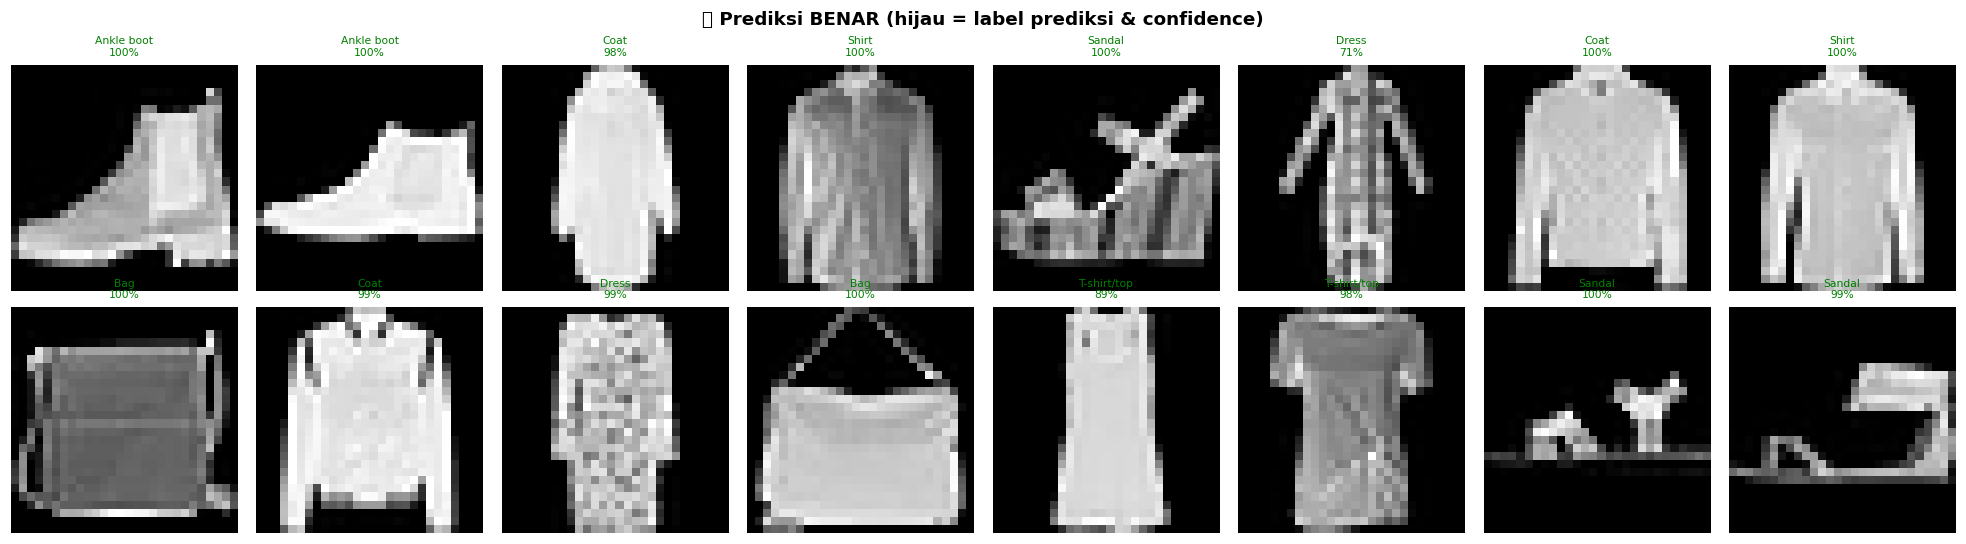

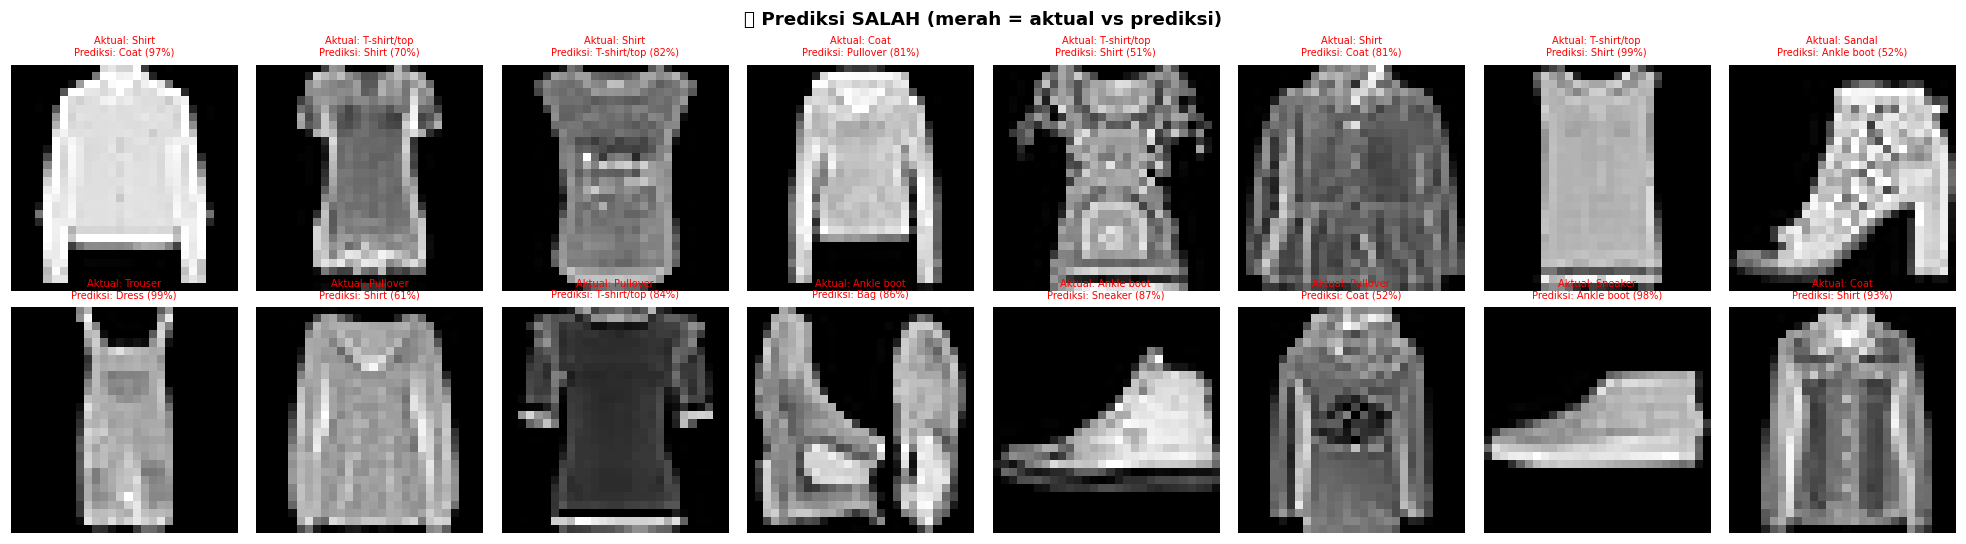

In [32]:
correct_idx = np.where(y_pred_label == y_true_label)[0]
wrong_idx   = np.where(y_pred_label != y_true_label)[0]

np.random.seed(42)

# Plot prediksi BENAR (8 gambar)
fig, axes = plt.subplots(2, 8, figsize=(18, 5))
sample_correct = np.random.choice(correct_idx, 16, replace=False)

for i, idx in enumerate(sample_correct):
    ax = axes[i // 8][i % 8]
    ax.imshow(X_test[idx].reshape(28, 28), cmap='gray')
    conf = y_pred_prob[idx][y_pred_label[idx]] * 100
    ax.set_title(f'{CLASS_NAMES[y_pred_label[idx]]}\n{conf:.0f}%',
                 fontsize=7, color='green')
    ax.axis('off')

plt.suptitle('✅ Prediksi BENAR (hijau = label prediksi & confidence)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

# Plot prediksi SALAH (16 gambar)
fig, axes = plt.subplots(2, 8, figsize=(18, 5))
sample_wrong = np.random.choice(wrong_idx, 16, replace=False)

for i, idx in enumerate(sample_wrong):
    ax = axes[i // 8][i % 8]
    ax.imshow(X_test[idx].reshape(28, 28), cmap='gray')
    true_lbl = CLASS_NAMES[y_true_label[idx]]
    pred_lbl = CLASS_NAMES[y_pred_label[idx]]
    conf     = y_pred_prob[idx][y_pred_label[idx]] * 100
    ax.set_title(f'Aktual: {true_lbl}\nPrediksi: {pred_lbl} ({conf:.0f}%)',
                 fontsize=6.5, color='red')
    ax.axis('off')

plt.suptitle('❌ Prediksi SALAH (merah = aktual vs prediksi)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

## 6. Analisis Error — Kategori Mana yang Sering Salah?

Analisis kesalahan per kelas untuk memahami kelemahan model.

📊 Error Rate per Kelas:


,Kelas,Total,Salah,Error Rate (%)
6,Shirt,1000,177,17.7
0,T-shirt/top,1000,115,11.5
4,Coat,1000,95,9.5
2,Pullover,1000,82,8.2
3,Dress,1000,52,5.2
9,Ankle boot,1000,29,2.9
7,Sneaker,1000,22,2.2
8,Bag,1000,13,1.3
5,Sandal,1000,12,1.2
1,Trouser,1000,10,1.0


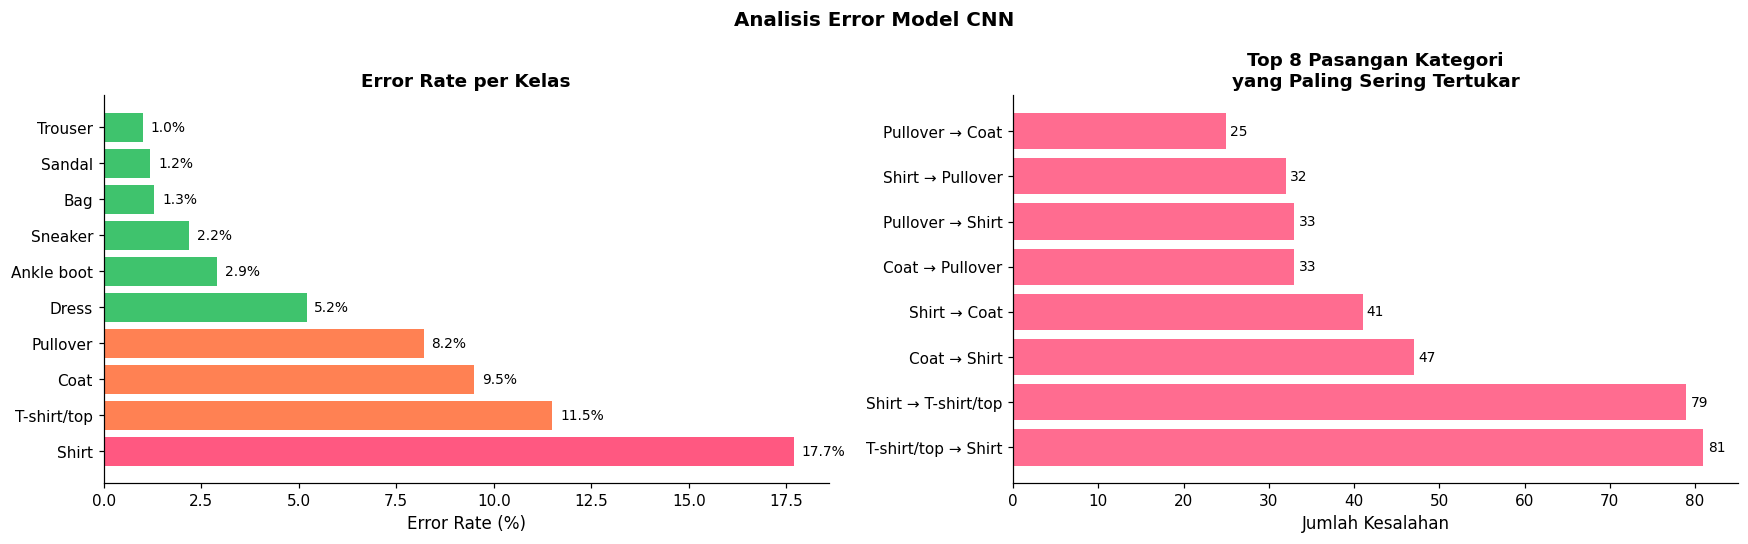

In [33]:
# Error rate per kelas
error_rates = []
for i in range(NUM_CLASSES):
    mask     = y_true_label == i
    n_total  = mask.sum()
    n_wrong  = (y_pred_label[mask] != i).sum()
    error_rates.append({
        'Kelas'        : CLASS_NAMES[i],
        'Total'        : n_total,
        'Salah'        : n_wrong,
        'Error Rate (%)': round(n_wrong / n_total * 100, 2)
    })

error_df = pd.DataFrame(error_rates).sort_values('Error Rate (%)', ascending=False)
print('📊 Error Rate per Kelas:')
display(error_df)

# Visualisasi
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Bar chart error rate
colors_err = [RED if e > 15 else ORANGE if e > 8 else GREEN
              for e in error_df['Error Rate (%)']]
axes[0].barh(error_df['Kelas'], error_df['Error Rate (%)'],
             color=colors_err, alpha=0.85)
axes[0].set_xlabel('Error Rate (%)', fontsize=11)
axes[0].set_title('Error Rate per Kelas', fontsize=12, fontweight='bold')
for i, (v, c) in enumerate(zip(error_df['Error Rate (%)'], error_df['Kelas'])):
    axes[0].text(v + 0.2, i, f'{v}%', va='center', fontsize=9)

# Heatmap top confusion pairs
cm_nodiag = cm.copy()
np.fill_diagonal(cm_nodiag, 0)
# Ambil top 5 pasangan yang sering tertukar
top_pairs = []
cm_flat   = cm_nodiag.flatten()
top_idx   = cm_flat.argsort()[-8:][::-1]
for idx in top_idx:
    i, j = divmod(idx, NUM_CLASSES)
    top_pairs.append({
        'Aktual'   : CLASS_NAMES[i],
        'Prediksi' : CLASS_NAMES[j],
        'Jumlah'   : cm_nodiag[i, j]
    })

pairs_df = pd.DataFrame(top_pairs)
axes[1].barh(
    [f"{r['Aktual']} → {r['Prediksi']}" for _, r in pairs_df.iterrows()],
    pairs_df['Jumlah'],
    color=RED, alpha=0.75
)
axes[1].set_xlabel('Jumlah Kesalahan', fontsize=11)
axes[1].set_title('Top 8 Pasangan Kategori\nyang Paling Sering Tertukar',
                  fontsize=12, fontweight='bold')
for i, v in enumerate(pairs_df['Jumlah']):
    axes[1].text(v + 0.5, i, str(v), va='center', fontsize=9)

plt.suptitle('Analisis Error Model CNN', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 7. Visualisasi Filter CNN

Lihat filter (kernel) yang dipelajari model di layer Conv2D pertama — ini adalah 'mata' model dalam melihat gambar.

Shape filter layer pertama: (3, 3, 1, 32)
→ 32 filter, ukuran 3×3


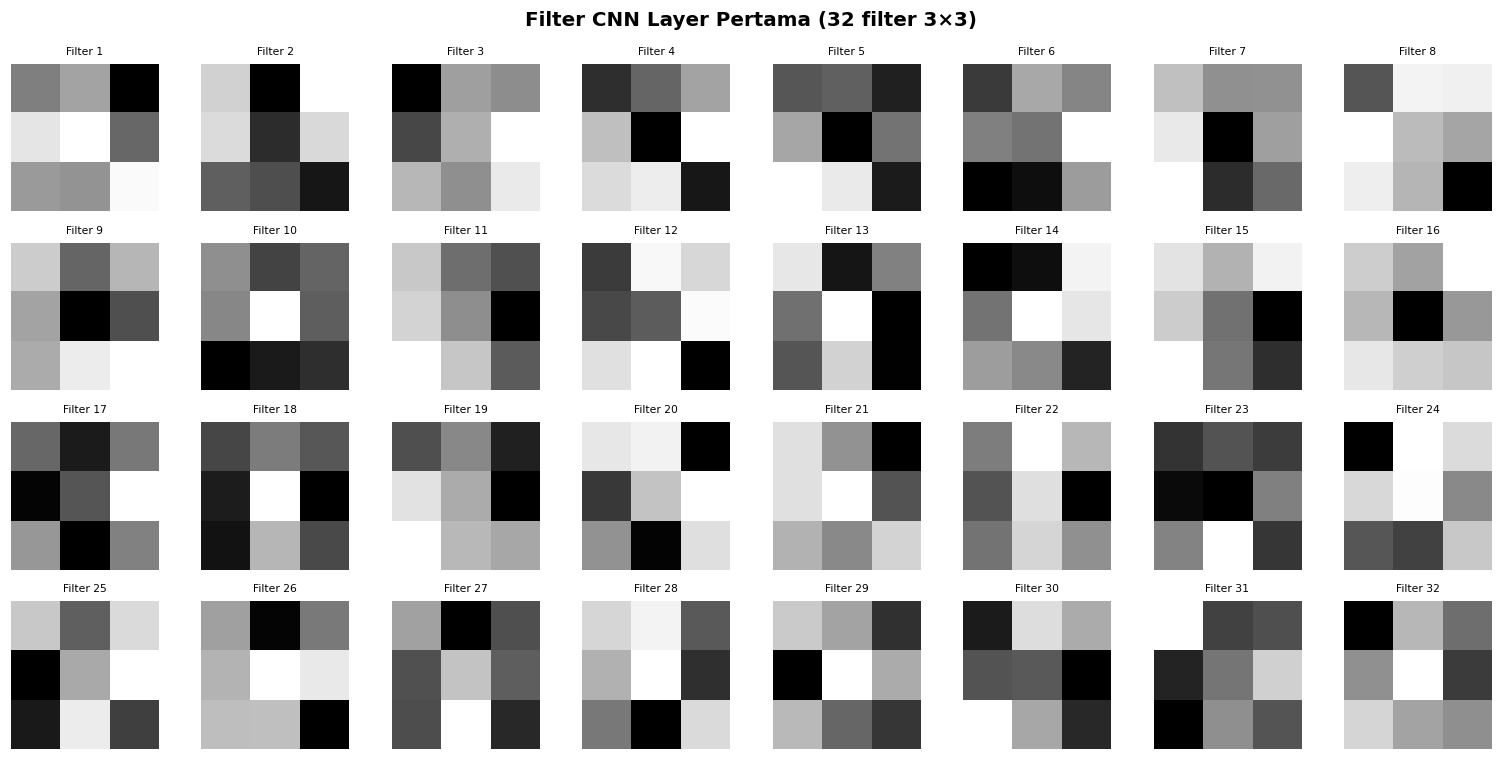

💡 Setiap filter belajar mendeteksi fitur berbeda:
   → Tepi horizontal, vertikal, diagonal
   → Tekstur dan pola tertentu
   → Kombinasi fitur yang membedakan antar kelas pakaian


In [34]:
# Ambil bobot layer Conv2D pertama
first_conv = None
for layer in model_cnn.layers:
    if 'conv2d' in layer.name:
        first_conv = layer
        break

filters, biases = first_conv.get_weights()
print(f'Shape filter layer pertama: {filters.shape}')
print(f'→ {filters.shape[3]} filter, ukuran {filters.shape[0]}×{filters.shape[1]}')

# Normalisasi filter ke range 0-1 untuk visualisasi
f_min, f_max = filters.min(), filters.max()
filters_norm = (filters - f_min) / (f_max - f_min)

# Tampilkan 32 filter pertama
fig, axes = plt.subplots(4, 8, figsize=(14, 7))
axes = axes.flatten()

for i in range(32):
    axes[i].imshow(filters_norm[:, :, 0, i], cmap='gray')
    axes[i].set_title(f'Filter {i+1}', fontsize=7)
    axes[i].axis('off')

plt.suptitle('Filter CNN Layer Pertama (32 filter 3×3)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('💡 Setiap filter belajar mendeteksi fitur berbeda:')
print('   → Tepi horizontal, vertikal, diagonal')
print('   → Tekstur dan pola tertentu')
print('   → Kombinasi fitur yang membedakan antar kelas pakaian')

✅ Feature maps shape: (1, 28, 28, 32)


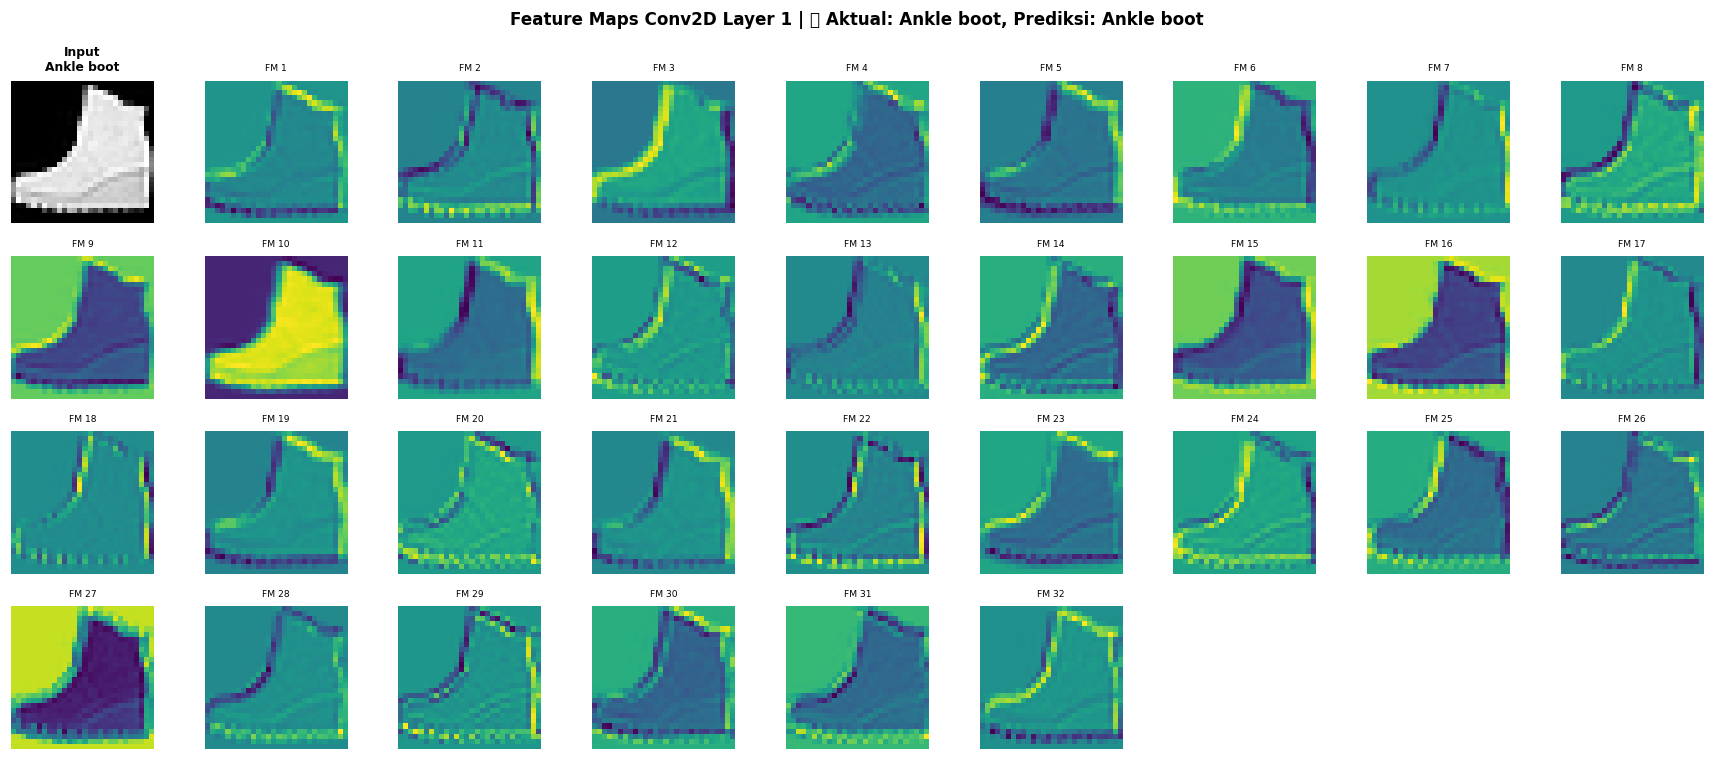

In [35]:
# Visualisasi feature maps — apa yang 'dilihat' CNN pada satu gambar
# Fix Keras 3: tidak pakai Model(inputs, outputs) tapi loop manual per layer

np.random.seed(7)
sample_idx   = np.random.choice(len(X_test))
sample_img   = X_test[sample_idx:sample_idx+1]
sample_label = CLASS_NAMES[y_true_label[sample_idx]]
sample_pred  = CLASS_NAMES[y_pred_label[sample_idx]]

# Jalankan tiap layer secara manual sampai Conv2D pertama
x         = sample_img
feat_maps = None
for layer in model_cnn.layers:
    x = layer(x, training=False)
    if 'conv2d' in layer.name:
        feat_maps = x.numpy()  # simpan output Conv2D pertama
        break

print(f'✅ Feature maps shape: {feat_maps.shape}')  # (1, 28, 28, 32)

fig = plt.figure(figsize=(16, 7))

# Gambar asli
ax0 = fig.add_subplot(4, 9, 1)
ax0.imshow(sample_img[0].reshape(28, 28), cmap='gray')
ax0.set_title(f'Input\n{sample_label}', fontsize=8, fontweight='bold')
ax0.axis('off')

# Feature maps (32 channel)
for i in range(min(32, feat_maps.shape[-1])):
    ax = fig.add_subplot(4, 9, i + 2)
    ax.imshow(feat_maps[0, :, :, i], cmap='viridis')
    ax.set_title(f'FM {i+1}', fontsize=6)
    ax.axis('off')

correct = '✅' if sample_label == sample_pred else '❌'
plt.suptitle(
    f'Feature Maps Conv2D Layer 1 | {correct} Aktual: {sample_label}, Prediksi: {sample_pred}',
    fontsize=11, fontweight='bold'
)
plt.tight_layout()
plt.show()

## 8. Ringkasan Temuan

In [36]:
print('=' * 60)
print('📋 RINGKASAN EVALUASI — FASHION MNIST CNN')
print('=' * 60)

worst_idx  = np.argmin(f1_scores)
best_idx   = np.argmax(f1_scores)
conf_pair  = f'{CLASS_NAMES[most_confused[0]]} → {CLASS_NAMES[most_confused[1]]}'

print(f'''
PERFORMA MODEL
┌──────────────────────────────────────────┐
  Test Accuracy : {acc_c*100:.2f}%
  Test Loss     : {loss_c:.4f}
  Prediksi benar: {n_correct:,} / {len(y_test_raw):,} gambar
└──────────────────────────────────────────┘

PER KELAS
  🏆 Kelas terbaik   : {CLASS_NAMES[best_idx]} (F1={max(f1_scores):.3f})
  ⚠️  Kelas tersulit  : {CLASS_NAMES[worst_idx]} (F1={min(f1_scores):.3f})
  🔄 Paling tertukar : {conf_pair}

INSIGHT
  → Shirt dan T-shirt/Pullover sering tertukar
    karena secara visual sangat mirip
  → Trouser, Bag, Sneaker mudah diklasifikasi
    karena bentuknya unik
  → Model bisa ditingkatkan dengan:
     • Data augmentation (flip, zoom, rotation)
     • Arsitektur lebih dalam (ResNet, EfficientNet)
     • Fine-tuning learning rate
''')
print('🎉 Semua notebook selesai! Project siap untuk portofolio.')

📋 RINGKASAN EVALUASI — FASHION MNIST CNN

PERFORMA MODEL
┌──────────────────────────────────────────┐
  Test Accuracy : 93.93%
  Test Loss     : 0.1830
  Prediksi benar: 9,393 / 10,000 gambar
└──────────────────────────────────────────┘

PER KELAS
  🏆 Kelas terbaik   : Trouser (F1=0.993)
  ⚠️  Kelas tersulit  : Shirt (F1=0.821)
  🔄 Paling tertukar : T-shirt/top → Shirt

INSIGHT
  → Shirt dan T-shirt/Pullover sering tertukar
    karena secara visual sangat mirip
  → Trouser, Bag, Sneaker mudah diklasifikasi
    karena bentuknya unik
  → Model bisa ditingkatkan dengan:
     • Data augmentation (flip, zoom, rotation)
     • Arsitektur lebih dalam (ResNet, EfficientNet)
     • Fine-tuning learning rate

🎉 Semua notebook selesai! Project siap untuk portofolio.
